In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [92]:
df = pd.read_csv('diamonds.csv')

In [93]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [94]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [95]:
#As seen from the data set the unnamed is nothing but starts from 1 and ends at 53940. This information is not vital for our analysis so we will remove it
df1 = df.copy()

In [96]:
# I have created a copy of the dataset since its not a good habit to work with the orginal data and remove columns from it
df1.drop('Unnamed: 0',axis =1, inplace = True)

In [97]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [98]:
df1.shape

(53940, 10)

In [99]:
df1.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [100]:
df1.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [101]:
correlation = df1[['carat','depth','table','x','y','z', 'price']].corr()


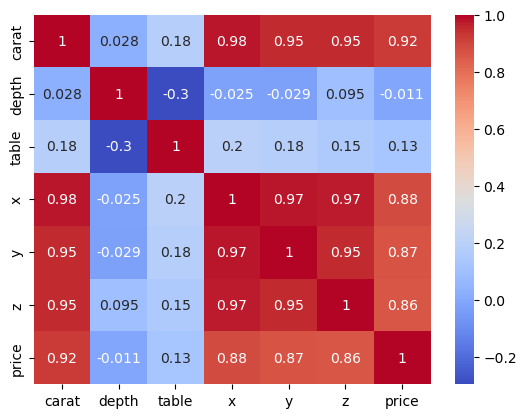

In [102]:
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()


In [103]:
# as seen from the graph the price is positively correlated with the x,y,z features and with the carat
print(correlation['price'])

carat    0.921591
depth   -0.010647
table    0.127134
x        0.884435
y        0.865421
z        0.861249
price    1.000000
Name: price, dtype: float64


/var/folders/0k/07ldk2fn76v9l5gr9yxytv540000gn/T/ipykernel_23821/361760381.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1['price'], color ='blue')


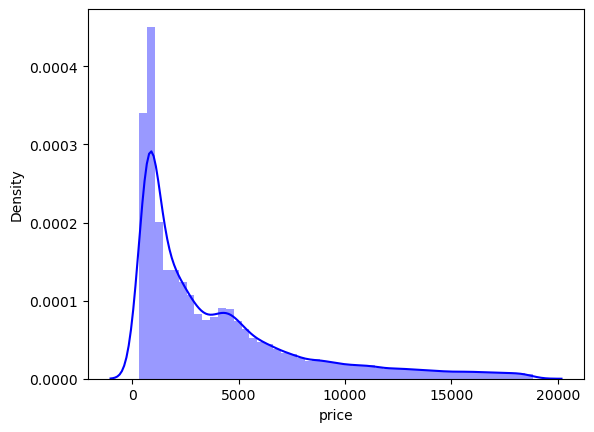

In [104]:
# One important feature to note is that the depth of the diamond is negatively correlated with the price of the diamond this means as the price increases the depth of the diamond decreases.
# checking the distribution of the price 
sns.distplot(df1['price'], color ='blue')
plt.show()

In [105]:
# the price is positively skewed, Most diamonds are low to moderately priced (bars concentrated on the left)
#A small number of very expensive diamonds create a long tail to the right
#The mean price is greater than the median

In [117]:
#Splitting the features and target
df_encoded = pd.get_dummies(df1, columns=['cut', 'color', 'clarity'], drop_first=True)

X = df_encoded.drop('price', axis=1)
Y = df_encoded['price']


In [118]:
print(X)

       carat  depth  table     x     y     z  cut_Good  cut_Ideal  \
0       0.23   61.5   55.0  3.95  3.98  2.43     False       True   
1       0.21   59.8   61.0  3.89  3.84  2.31     False      False   
2       0.23   56.9   65.0  4.05  4.07  2.31      True      False   
3       0.29   62.4   58.0  4.20  4.23  2.63     False      False   
4       0.31   63.3   58.0  4.34  4.35  2.75      True      False   
...      ...    ...    ...   ...   ...   ...       ...        ...   
53935   0.72   60.8   57.0  5.75  5.76  3.50     False       True   
53936   0.72   63.1   55.0  5.69  5.75  3.61      True      False   
53937   0.70   62.8   60.0  5.66  5.68  3.56     False      False   
53938   0.86   61.0   58.0  6.15  6.12  3.74     False      False   
53939   0.75   62.2   55.0  5.83  5.87  3.64     False       True   

       cut_Premium  cut_Very Good  ...  color_H  color_I  color_J  clarity_IF  \
0            False          False  ...    False    False    False       False   
1        

In [119]:
print(Y)

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53940, dtype: int64


In [120]:
# splitting into training and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [127]:
#model training random forest regressor
regressor = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [128]:
regressor.fit(X_train, Y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [129]:
#prediction on the data
test_data_prediction = regressor.predict(X_test)

In [130]:
error_score = metrics.r2_score(Y_test, test_data_prediction)

In [131]:
print('R squared error:', error_score)

R squared error: 0.973741268470017


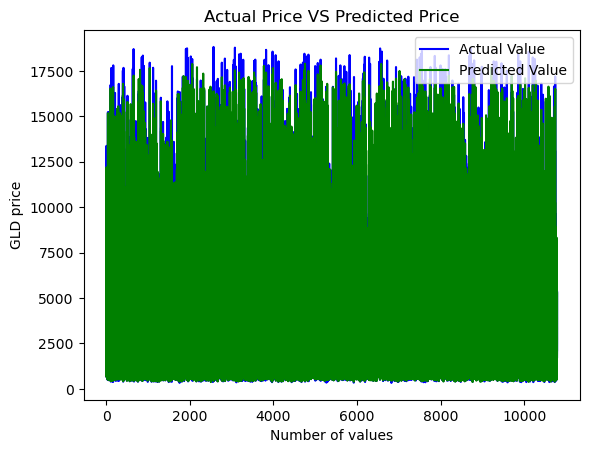

In [132]:
#compare the actual values
Y_test= list(Y_test)
plt.plot(Y_test, color= 'blue', label='Actual Value')
plt.plot(test_data_prediction, color= 'green', label= 'Predicted Value')
plt.title("Actual Price VS Predicted Price")
plt.xlabel('Number of values')
plt.ylabel('GLD price')
plt.legend()
plt.show()

In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("R²:", metrics.r2_score(Y_test, test_data_prediction))
print("MAE:", mean_absolute_error(Y_test, test_data_prediction))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, test_data_prediction)))


R²: 0.973741268470017
MAE: 300.8313710400084
RMSE: 644.6354279933827
